In [1]:

import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/package/STAGATE_pyG-main")
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem/")

In [2]:
import STAGATE_pyG
import scanpy as sc
import pandas as pd

/public/home/off_liukunpeng/.conda/envs/STMGraph_singularity/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
os.environ['R_HOME'] = "/public/home/off_liukunpeng/.conda/envs/STMGraph_singularity/lib/R"

In [4]:
adata=sc.read_visium("/public/home/off_liukunpeng/project/7_public_data/Data/osfstorage-archive/Slide_1/",count_file="filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()

/tmp/ipykernel_4823/1175087418.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata=sc.read_visium("/public/home/off_liukunpeng/project/7_public_data/Data/osfstorage-archive/Slide_1/",count_file="filtered_feature_bc_matrix.h5")


------Calculating spatial graph...
The graph contains 13592 edges, 2379 cells.
5.7133 neighbors per cell on average.


/public/home/off_liukunpeng/project/11_cluster_problem/package/STAGATE_pyG-main/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/package/STAGATE_pyG-main/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


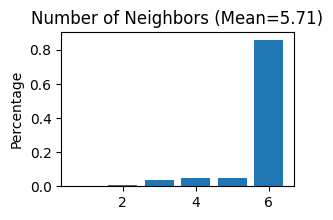

In [5]:
adata.var_names_make_unique()

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

STAGATE_pyG.Cal_Spatial_Net(adata, rad_cutoff=500)
STAGATE_pyG.Stats_Spatial_Net(adata)

In [6]:


import torch
adata = STAGATE_pyG.train_STAGATE(adata,device=torch.device('cuda:3'),random_seed=1)

sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)
# print(adata)


Size of Input:  (2379, 3000)


100%|██████████| 1000/1000 [00:18<00:00, 54.40it/s]


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


<Axes: title={'center': 'mclust'}, xlabel='spatial1', ylabel='spatial2'>

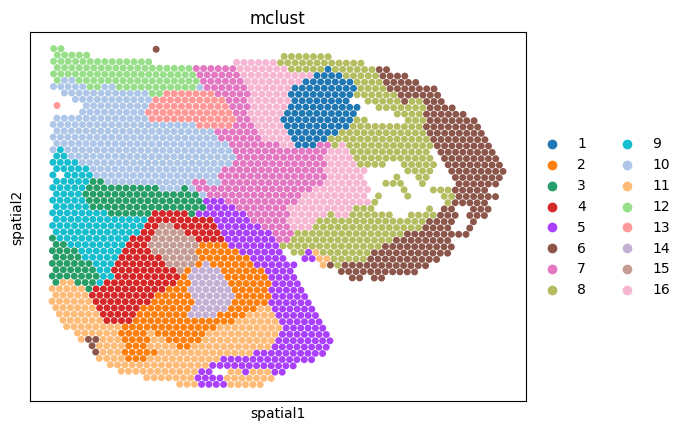

In [7]:
adata = STAGATE_pyG.mclust_R(adata, used_obsm='STAGATE', num_cluster=16)
# print(adata)
# adata_save=adata[:,0].copy()

# adata_save.obsm["STAGATE"]=adata.obsm["STAGATE"]
sc.pl.embedding(adata, basis='spatial', color="mclust", s=100, show=False)

In [8]:
adata

AnnData object with n_obs × n_vars = 2379 × 28903
    obs: 'in_tissue', 'array_row', 'array_col', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'Spatial_Net', 'neighbors', 'umap', 'mclust_colors'
    obsm: 'spatial', 'STAGATE', 'X_umap'
    obsp: 'distances', 'connectivities'

[<Axes: title={'center': '1 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '2 vs. rest'}>,
 <Axes: title={'center': '3 vs. rest'}>,
 <Axes: title={'center': '4 vs. rest'}>,
 <Axes: title={'center': '5 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '6 vs. rest'}>,
 <Axes: title={'center': '7 vs. rest'}>,
 <Axes: title={'center': '8 vs. rest'}>,
 <Axes: title={'center': '9 vs. rest'}, ylabel='score'>,
 <Axes: title={'center': '10 vs. rest'}>,
 <Axes: title={'center': '11 vs. rest'}>,
 <Axes: title={'center': '12 vs. rest'}>,
 <Axes: title={'center': '13 vs. rest'}, xlabel='ranking', ylabel='score'>,
 <Axes: title={'center': '14 vs. rest'}, xlabel='ranking'>,
 <Axes: title={'center': '15 vs. rest'}, xlabel='ranking'>,
 <Axes: title={'center': '16 vs. rest'}, xlabel='ranking'>]

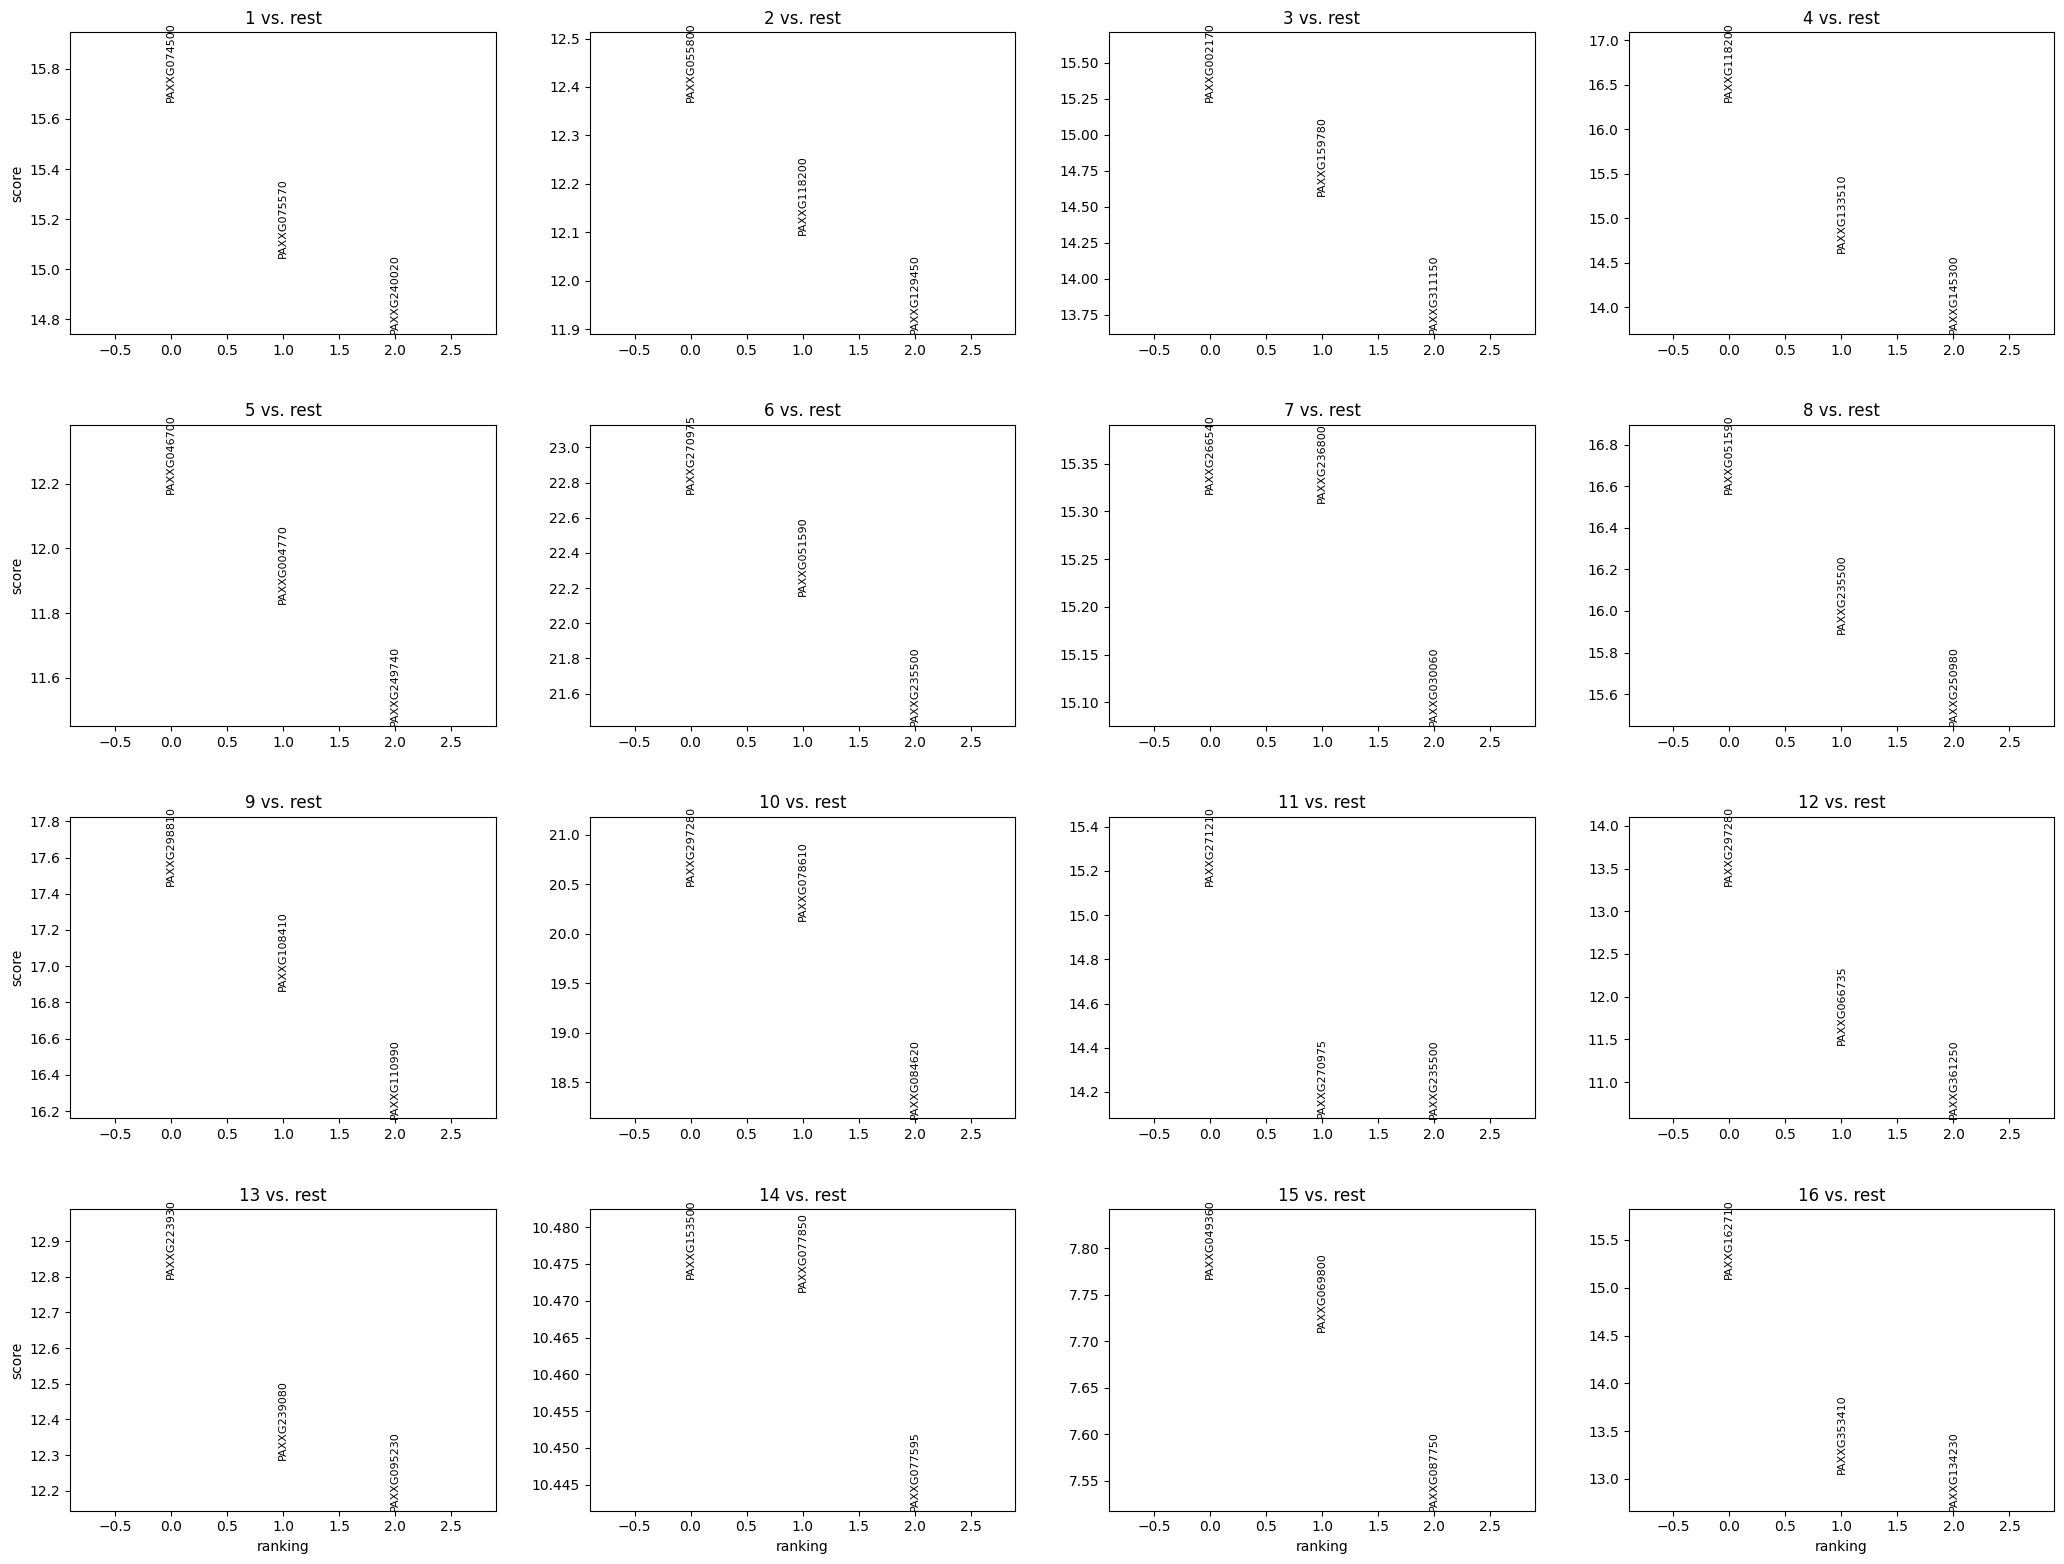

In [9]:
# fig,ax=plt.subplots(2,3,figsize=(9,3))

sc.tl.rank_genes_groups(adata, "mclust", method="wilcoxon")
# sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
# sc.pl.rank_genes_groups(adata, n_genes=25,groups="2",ax=ax[0,1],sharey=False,show=False)
# sc.pl.rank_genes_groups(adata, n_genes=25,groups=["2"],sharey=False)
sc.pl.rank_genes_groups(adata, n_genes=3,sharey=False,show=False)


/tmp/ipykernel_4823/1430685911.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


[<Axes: title={'center': 'PAXXG051590'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG235500'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG250980'}, xlabel='spatial1', ylabel='spatial2'>]

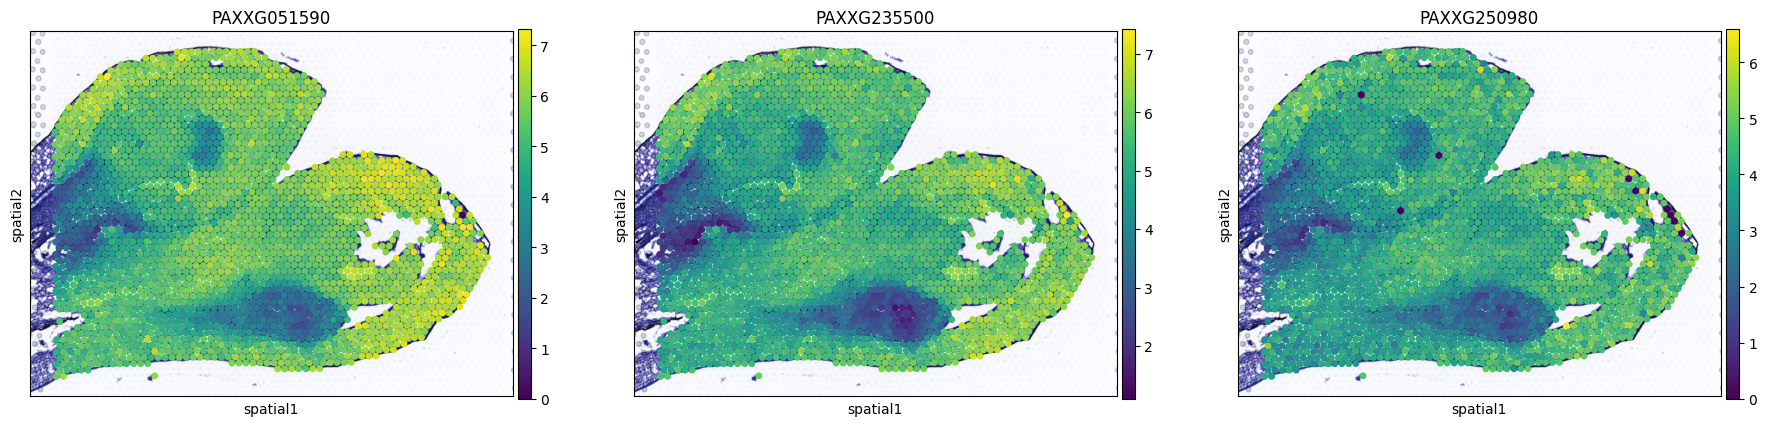

In [10]:
plot_gene=sc.get.rank_genes_groups_df(adata,group="8")["names"][0:3].tolist()
sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


/tmp/ipykernel_4823/2849455790.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


[<Axes: title={'center': 'PAXXG298810'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG108410'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG110990'}, xlabel='spatial1', ylabel='spatial2'>]

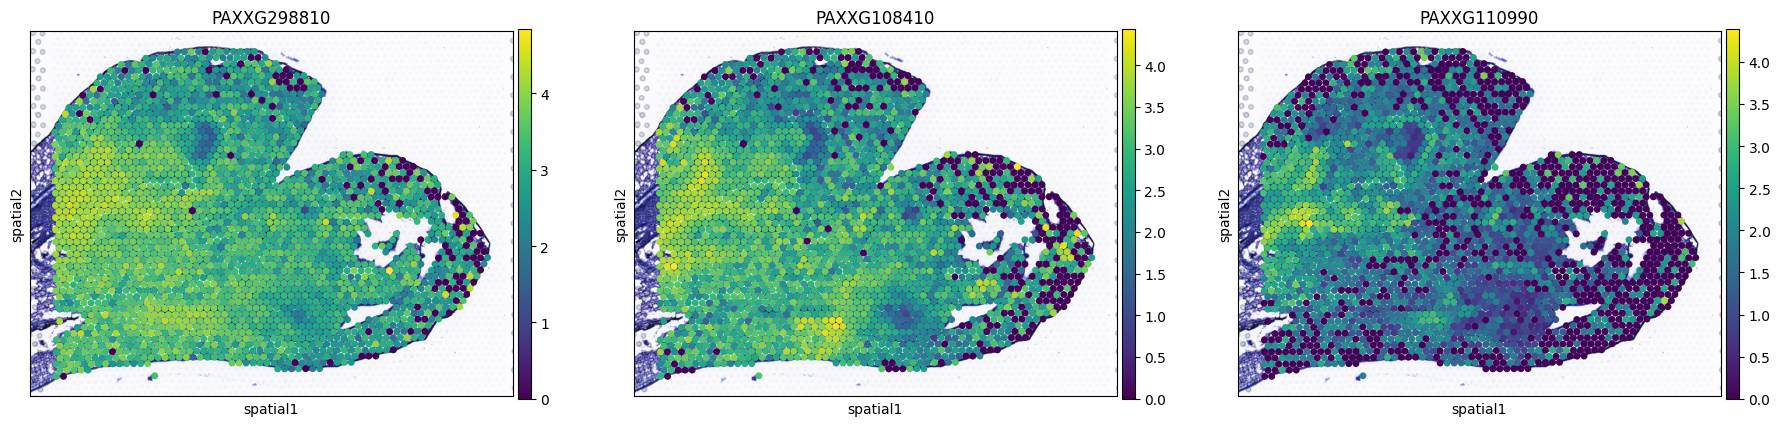

In [11]:
plot_gene=sc.get.rank_genes_groups_df(adata,group="9")["names"][0:3].tolist()
sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


/tmp/ipykernel_4823/1855473062.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


[<Axes: title={'center': 'PAXXG074500'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG075570'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'PAXXG240020'}, xlabel='spatial1', ylabel='spatial2'>]

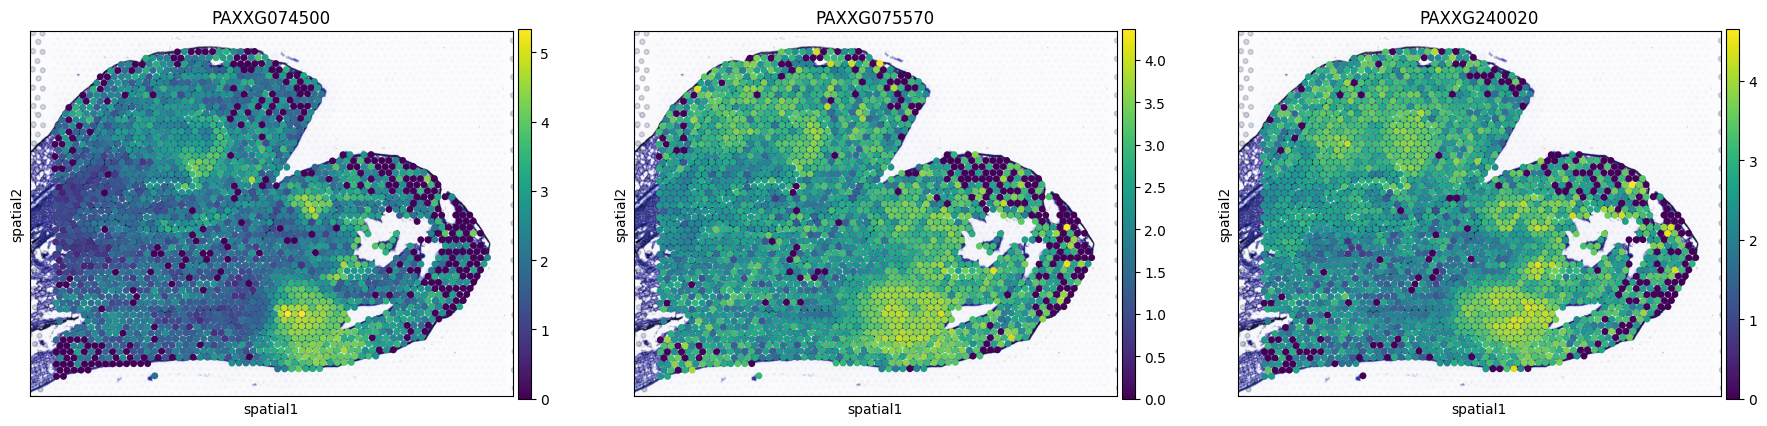

In [12]:
plot_gene=sc.get.rank_genes_groups_df(adata,group="1")["names"][0:3].tolist()
sc.pl.spatial(adata, basis='spatial', color=plot_gene,  s=12, show=False)


In [13]:
adata

AnnData object with n_obs × n_vars = 2379 × 28903
    obs: 'in_tissue', 'array_row', 'array_col', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'Spatial_Net', 'neighbors', 'umap', 'mclust_colors', 'rank_genes_groups'
    obsm: 'spatial', 'STAGATE', 'X_umap'
    obsp: 'distances', 'connectivities'

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
adata.uns['iroot'] = np.flatnonzero(adata.obs["mclust"] == 4)[0]

sc.pp.neighbors(adata,use_rep='STAGATE')
sc.tl.diffmap(adata)
sc.tl.dpt(adata)
pSM_values = adata.obs['dpt_pseudotime'].to_numpy()


# Ploting figures
matplotlib.rcParams['font.size'] = 8.0
# fig, axes = plt.subplots(1, 1, figsize=(3,3))
sz = 10
x = np.array(adata.obsm['spatial'][:,0])
y = np.array(adata.obsm['spatial'][:,1])

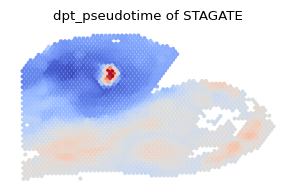

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(3,2))
ax_temp = axes
im = ax_temp.scatter(x, y, s=15, c=pSM_values, marker='.', cmap='coolwarm',alpha = 1)
ax_temp.axis('off')
ax_temp.set_title('dpt_pseudotime of STAGATE')
plt.tight_layout()
ax_temp.invert_yaxis()
# fig
fig.savefig("plot/fig5_pSM_stagate.png",dpi=300)

In [16]:
pSM_values.shape

(2379,)

In [17]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6201217 stored elements and shape (2379, 28903)>

In [18]:
adata.X.shape[1]

28903

In [37]:
adata.X[:,2].todense().T.tolist()[0]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

In [35]:
pSM_values.tolist()

[0.10211401432752609,
 0.45743849873542786,
 0.25992491841316223,
 0.1945498138666153,
 0.25872883200645447,
 0.5189183950424194,
 0.5227981805801392,
 0.31966161727905273,
 0.4848855137825012,
 0.535080075263977,
 0.2050643414258957,
 0.6054479479789734,
 0.3931829631328583,
 0.29270926117897034,
 0.5385764241218567,
 0.5453400015830994,
 0.0,
 0.03917529806494713,
 0.46392208337783813,
 0.34195876121520996,
 0.1928812563419342,
 0.22636602818965912,
 0.1823047697544098,
 0.3053622543811798,
 0.16178300976753235,
 0.5321836471557617,
 0.42895326018333435,
 0.4868105351924896,
 0.48374244570732117,
 0.4712904691696167,
 0.5057541728019714,
 0.22159071266651154,
 0.5160903334617615,
 0.4830763339996338,
 0.5072101354598999,
 0.10223772376775742,
 0.4343898594379425,
 0.5183669328689575,
 0.07968660444021225,
 0.5134195685386658,
 0.5143094658851624,
 0.4916127920150757,
 0.5108565092086792,
 0.25360551476478577,
 0.035655438899993896,
 0.49747151136398315,
 0.02796168252825737,
 0.43369

In [38]:
pearsonr(adata.X[:,2].todense().T.tolist()[0], pSM_values.tolist())

PearsonRResult(statistic=np.float64(0.01671087302866563), pvalue=np.float64(0.4152433430588441))

In [40]:
from scipy.stats import pearsonr
prs=[]
pvalue=[]
for i in range(adata.X.shape[1]):
    correlation_coefficient, p_value = pearsonr(adata.X[:,i].todense().T.tolist()[0], pSM_values.tolist())
    # print(correlation_coefficient)
    prs.append(correlation_coefficient)
    pvalue.append(p_value)

/tmp/ipykernel_34348/3474137662.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation_coefficient, p_value = pearsonr(adata.X[:,i].todense().T.tolist()[0], pSM_values.tolist())


In [41]:
adata.var["pSM_corr"]=prs
adata.var["pSM_corr_pvalue"]=pvalue

In [42]:
pSM_corr_gene=adata.var.loc[adata.var.loc[:,"pSM_corr_pvalue"]<0.05,:].sort_values("pSM_corr")
# pSM_corr_gene.loc[:,"name"]
head_gene=pSM_corr_gene.index[0:3]

pSM_corr_gene=adata.var.loc[adata.var.loc[:,"pSM_corr_pvalue"]<0.05,:].sort_values("pSM_corr",ascending=False)
# pSM_corr_gene.loc[:,"name"]
tail_gene=pSM_corr_gene.index[0:3]

In [45]:
pSM_corr_gene

,gene_ids,feature_types,genome,highly_variable,highly_variable_rank,means,variances,variances_norm,pSM_corr,pSM_corr_pvalue
PAXXG361250,PAXXG361250,Gene Expression,RefGenome,False,NaN,4.452711,26.857624,0.505098,0.347021,2.762506e-68
PAXXG031040,PAXXG031040,Gene Expression,RefGenome,True,843.0,1.230349,7.039432,1.373319,0.277235,3.089224e-43
PAXXG159830,PAXXG159830,Gene Expression,RefGenome,True,27.0,2.441782,62.359414,3.539397,0.264479,2.286931e-39
PAXXG292920,PAXXG292920,Gene Expression,RefGenome,True,130.0,0.811265,5.688082,2.221345,0.222917,3.582354e-28
PAXXG066735,PAXXG066735,Gene Expression,RefGenome,True,625.0,3.007146,37.753944,1.458414,0.215742,1.882513e-26
...,...,...,...,...,...,...,...,...,...,...
PAXXG029610,PAXXG029610,Gene Expression,RefGenome,True,2311.0,5.382514,85.867078,1.143593,-0.429094,3.524412e-107
PAXXG064060,PAXXG064060,Gene Expression,RefGenome,True,447.0,6.127785,150.752377,1.587437,-0.430446,6.459777e-108
PAXXG046700,PAXXG046700,Gene Expression,RefGenome,False,NaN,4.013451,33.698726,0.766175,-0.475953,8.912562e-135
PAXXG118210,PAXXG118210,Gene Expression,RefGenome,True,518.0,4.343001,77.264975,1.520770,-0.505770,1.023788e-154


In [43]:
print(list(head_gene))
print(list(tail_gene))
plot_gene=list(head_gene)+list(tail_gene)

['PAXXG118200', 'PAXXG118210', 'PAXXG046700']
['PAXXG361250', 'PAXXG031040', 'PAXXG159830']


/tmp/ipykernel_34348/2371065881.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[0,n], s=12, show=False)
/tmp/ipykernel_34348/2371065881.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[0,n], s=12, show=False)
/tmp/ipykernel_34348/2371065881.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[0,n], s=12, show=False)
/tmp/ipykernel_34348/2371065881.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[1,n], s=12, show=False)
/tmp/ipykernel_34348/2371065881.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[1,n], s=12, show=False)
/tmp/ipykernel_34348/2371065881.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, ba

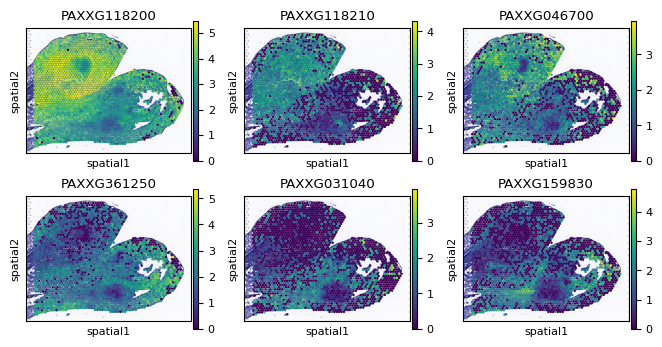

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(8,4))
# sc.pl.spatial(AgaeSMO__adata, basis='spatial', color=plot_gene,  s=12, show=False)
for n,i in enumerate(head_gene):
    sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[0,n], s=12, show=False)
for n,i in enumerate(tail_gene):
    sc.pl.spatial(adata, basis='spatial', color=i, ax=axes[1,n], s=12, show=False)
